<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

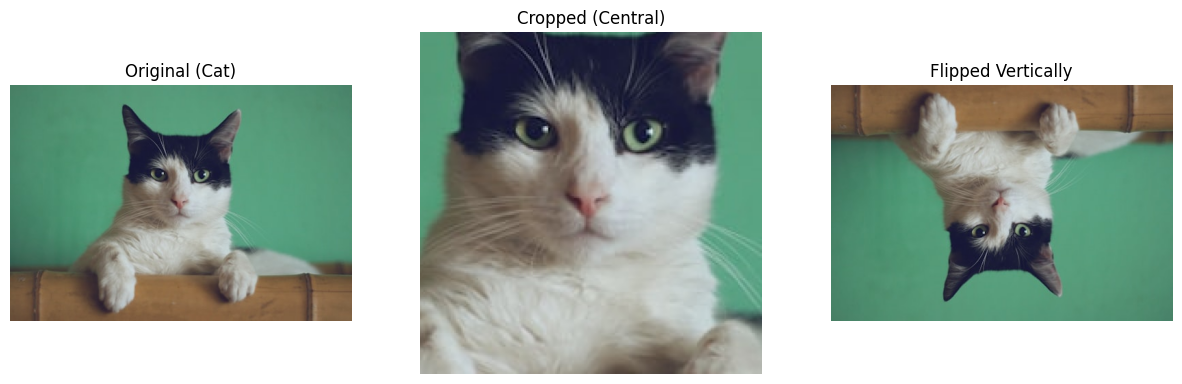

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from PIL import Image
from io import BytesIO

# Using a different reliable image source to avoid 403 Forbidden errors
image_url = "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?q=80&w=500&auto=format&fit=crop"
headers = {"User-Agent": "Mozilla/5.0"}

try:
    response = requests.get(image_url, headers=headers, timeout=10)
    response.raise_for_status()

    # Decode image
    pil_img = Image.open(BytesIO(response.content)).convert("RGB")
    img = np.array(pil_img)

    # 1. Crop the image (Central 200x200)
    h, w, _ = img.shape
    target_h, target_w = 200, 200
    start_y = max(0, (h - target_h) // 2)
    start_x = max(0, (w - target_w) // 2)
    crop_img = img[start_y:start_y+target_h, start_x:start_x+target_w]

    # 2. Flip the image vertically
    flip_img = img[::-1, :, :]

    # Displaying the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img)
    axes[0].set_title("Original (Cat)")
    axes[1].imshow(crop_img)
    axes[1].set_title("Cropped (Central)")
    axes[2].imshow(flip_img)
    axes[2].set_title("Flipped Vertically")
    for ax in axes: ax.axis("off")
    plt.show()

except Exception as e:
    print(f"Error loading image: {e}")

### 10.2 Introduction to Convolutional Neural Networks (CNNs)

Convolutional Neural Networks (CNNs) are a class of deep neural networks most commonly applied to analyze visual imagery. They are powerful tools for tasks like image classification, object detection, and image segmentation.

Here, we'll set up a basic CNN architecture using TensorFlow/Keras and demonstrate how to prepare an image for input into such a network.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2 # For image resizing, typically part of OpenCV, good for preprocessing

# Define a simple CNN model
model = keras.Sequential([
    layers.Input(shape=(200, 200, 3)), # Assuming we'll resize images to 200x200 with 3 color channels
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Example: 10 output classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 135424)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     8,667,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,724,170 (33.28 MB)

 Trainable params: 8,724,170 (33.28 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Prepare the 'img' from the previous cell for CNN input
# CNNs typically expect a fixed input size and a batch dimension.

# Resize the image to match the CNN input shape (e.g., 200x200)
resized_img = cv2.resize(img, (200, 200))

# Normalize pixel values to be between 0 and 1
normalized_img = resized_img.astype('float32') / 255.0

# Add a batch dimension (CNNs expect input in the shape [batch_size, height, width, channels])
cnn_input_img = np.expand_dims(normalized_img, axis=0)

print(f"Original image shape: {img.shape}")
print(f"Resized image shape: {resized_img.shape}")
print(f"Normalized image shape: {normalized_img.shape}")
print(f"CNN input shape (with batch dimension): {cnn_input_img.shape}")

# Demonstrate passing the image through the model (without training)
# This will show the output of the first layer or the final prediction layer if it was trained.
output_features = model.predict(cnn_input_img)
print(f"Output features shape from CNN: {output_features.shape}")

Original image shape: (512, 512, 3)
Resized image shape: (200, 200, 3)
Normalized image shape: (200, 200, 3)
CNN input shape (with batch dimension): (1, 200, 200, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
Output features shape from CNN: (1, 10)


### 10.3 Applying CNN to Rotated Images

Now, let's take the cropped and flipped images and rotate them at different angles (0, 90, 180, 270 degrees). We'll then preprocess these rotated images for the CNN model and pass them through to see the output feature shapes. This demonstrates how to handle various orientations of an image with a CNN.

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_for_cnn(image, target_size=(200, 200)):
    """Resizes, normalizes, and adds batch dimension to an image for CNN input."""
    resized_img = cv2.resize(image, target_size)
    normalized_img = resized_img.astype('float32') / 255.0
    cnn_input = np.expand_dims(normalized_img, axis=0)
    return cnn_input

# Dictionary to store rotated images and their CNN outputs
rotated_images = {
    'cropped': {},
    'flipped': {}
}
cnn_outputs = {
    'cropped': {},
    'flipped': {}
}

angles = [0, 90, 180, 270]

for angle in angles:
    # Rotate cropped image
    if angle == 0:
        rotated_crop = crop_img.copy() # No rotation needed
    elif angle == 90:
        rotated_crop = cv2.rotate(crop_img, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        rotated_crop = cv2.rotate(crop_img, cv2.ROTATE_180)
    elif angle == 270:
        rotated_crop = cv2.rotate(crop_img, cv2.ROTATE_90_COUNTERCLOCKWISE)

    rotated_images['cropped'][angle] = rotated_crop
    cnn_input_crop = preprocess_for_cnn(rotated_crop)
    cnn_outputs['cropped'][angle] = model.predict(cnn_input_crop)

    # Rotate flipped image
    if angle == 0:
        rotated_flip = flip_img.copy() # No rotation needed
    elif angle == 90:
        rotated_flip = cv2.rotate(flip_img, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        rotated_flip = cv2.rotate(flip_img, cv2.ROTATE_180)
    elif angle == 270:
        rotated_flip = cv2.rotate(flip_img, cv2.ROTATE_90_COUNTERCLOCKWISE)

    rotated_images['flipped'][angle] = rotated_flip
    cnn_input_flip = preprocess_for_cnn(rotated_flip)
    cnn_outputs['flipped'][angle] = model.predict(cnn_input_flip)

print("--- CNN Output Shapes for Cropped Image Rotations ---")
for angle, output in cnn_outputs['cropped'].items():
    print(f"Cropped image (rotated {angle} degrees): {output.shape}")

print("\n--- CNN Output Shapes for Flipped Image Rotations ---")
for angle, output in cnn_outputs['flipped'].items():
    print(f"Flipped image (rotated {angle} degrees): {output.shape}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
--- CNN Output Shapes for Cropped Image Rotations ---
Cropped image (rotated 0 degrees): (1, 10)
Cropped image (rotated 90 degrees): (1, 10)
Cropped image (rotated 180 degrees): (1, 10)
Cropped image (rotated 270 degrees): (1, 10)

--- CNN Output Shapes for Flipped Image Rotations ---
Flipped image (rotated 0 degrees): (1, 10)
Flipped image (rotated 90 degrees): (1, 10)
Flipped image (rotated 180 degrees): (1, 10)
Flipped image (rotated 270 degrees): (1, 10)


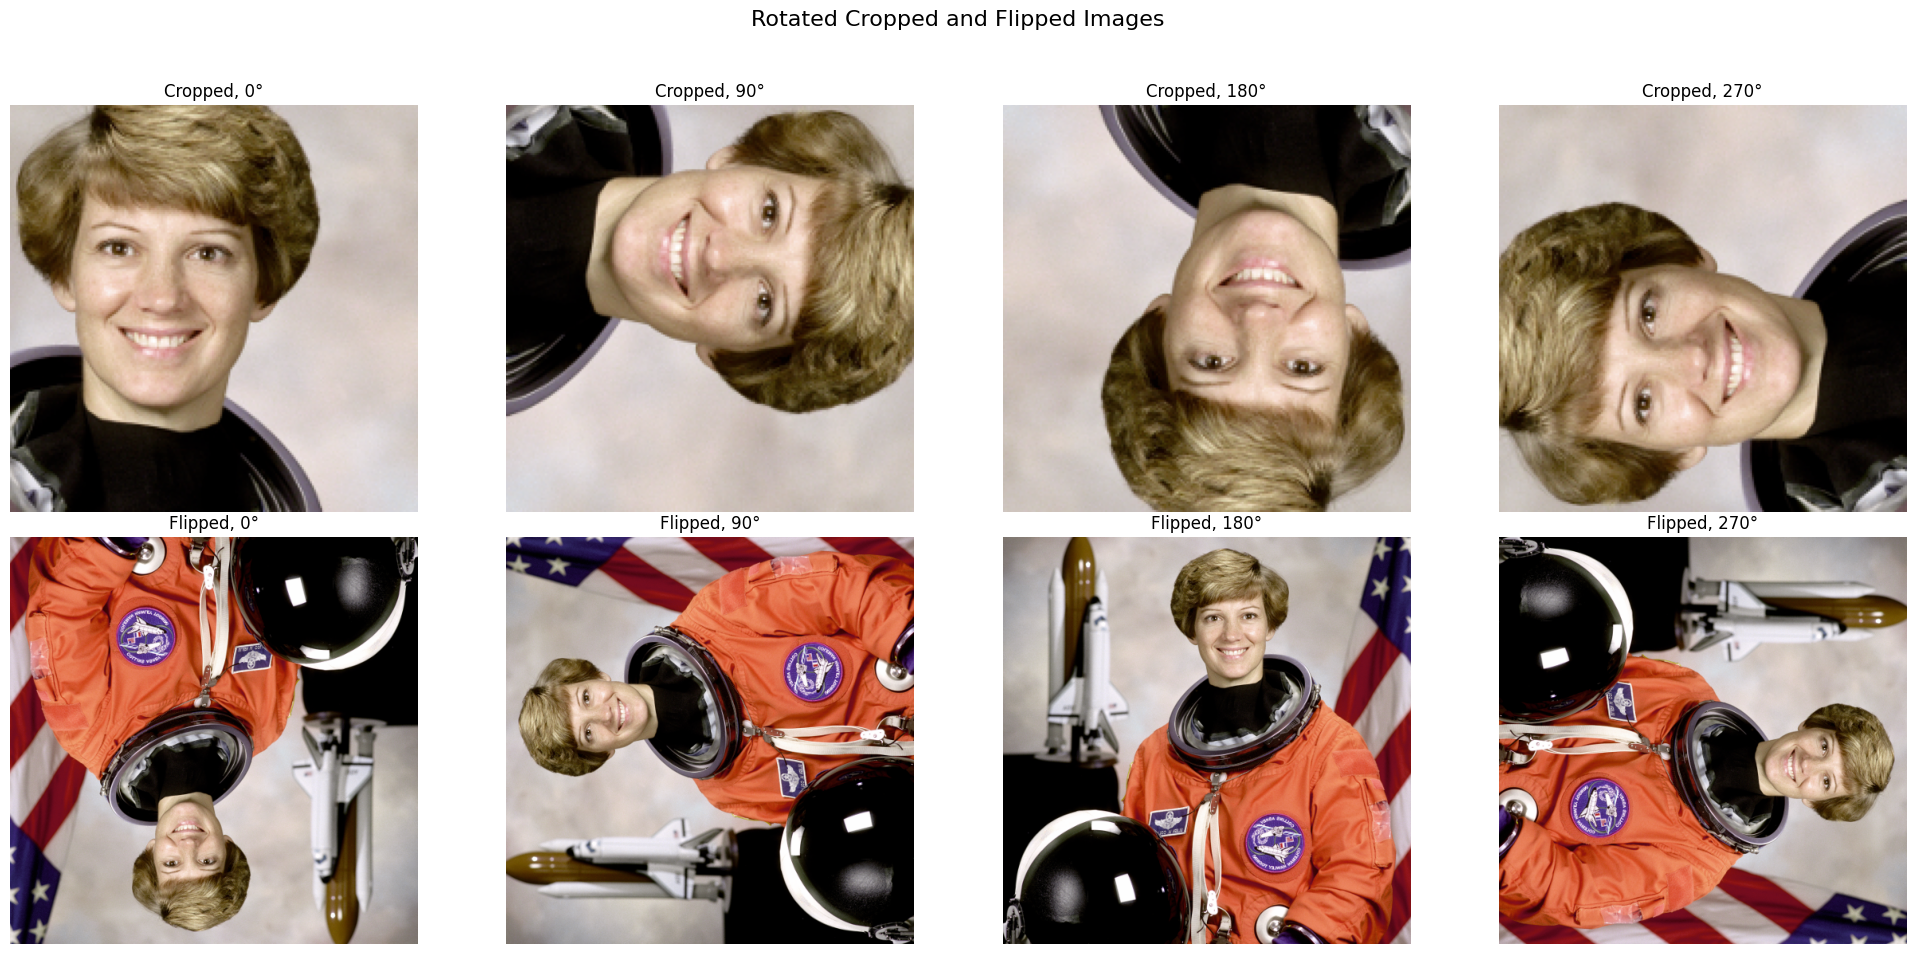

In [5]:
# Displaying the rotated images
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Rotated Cropped and Flipped Images', fontsize=16)

for i, angle in enumerate(angles):
    # Cropped images
    axes[0, i].imshow(rotated_images['cropped'][angle])
    axes[0, i].set_title(f"Cropped, {angle}°")
    axes[0, i].axis('off')

    # Flipped images
    axes[1, i].imshow(rotated_images['flipped'][angle])
    axes[1, i].set_title(f"Flipped, {angle}°")
    axes[1, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()